In [79]:
!pip install -q datasets tensorflow scikit-learn pandas numpy matplotlib seaborn shap joblib fastapi uvicorn pydantic


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json

warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


In [81]:
from datasets import load_dataset

dataset = load_dataset(
    "Abdulmajeedyahya/1M-Fraud-Labeled-Synthetic-Bank-Transactions",
    split="train"
)

df = dataset.to_pandas()

print("Dataset loaded successfully")
print("Shape:", df.shape)

Repo card metadata block was not found. Setting CardData to empty.


Dataset loaded successfully
Shape: (5000, 43)


In [82]:
df.head()

,transaction_id,customer_id,customer_segment,account_type,transaction_timestamp,transaction_date,transaction_hour,transaction_dow,is_weekend,is_holiday,...,country,distance_from_home_km,credit_limit,credit_utilization,credit_score,account_age_days,transaction_velocity_1h,chargeback_flag,fraud_label,fraud_type
0,02d82794-f2a2-41f9-bce1-9cf95962a807,ACC384262F4DB19,SMALL_BUSINESS,CREDIT,2022-01-01 00:50:47,2022-01-01,0,5,1,1,...,US,4129.1,102732.29,0.41,582,2719,1,False,0,LEGITIMATE
1,1ad78c7d-5ad1-47ed-9616-ac4f5b22e57c,ACCBB6DD861003C,SMALL_BUSINESS,CREDIT,2022-01-01 01:08:26,2022-01-01,1,5,1,1,...,US,3935.2,151031.58,0.53,543,3310,1,False,0,LEGITIMATE
2,9e496ec9-a86c-488c-aa85-0d91dd19c966,ACC8A28288E8C78,FREQUENT_TRAVELER,CHECKING,2022-01-01 01:47:42,2022-01-01,1,5,1,1,...,KR,11052.4,112887.72,0.43,567,3286,1,False,0,LEGITIMATE
3,2b16f7e5-6abc-4f03-863e-63ddc1bb597b,ACCD2D5BAA7473E,MASS_RETAIL,CHECKING,2022-01-01 01:49:04,2022-01-01,1,5,1,1,...,CA,550.0,9891.87,0.51,748,441,1,False,0,LEGITIMATE
4,acab8f06-f271-4da0-b2c0-4cb89fe26dd6,ACC119C24334FEE,MASS_RETAIL,CREDIT,2022-01-01 02:02:02,2022-01-01,2,5,1,1,...,US,2205.4,48206.24,0.52,732,1524,5,False,0,LEGITIMATE


In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           5000 non-null   str    
 1   customer_id              5000 non-null   str    
 2   customer_segment         5000 non-null   str    
 3   account_type             5000 non-null   str    
 4   transaction_timestamp    5000 non-null   str    
 5   transaction_date         5000 non-null   str    
 6   transaction_hour         5000 non-null   int64  
 7   transaction_dow          5000 non-null   int64  
 8   is_weekend               5000 non-null   int64  
 9   is_holiday               5000 non-null   int64  
 10  month                    5000 non-null   int64  
 11  quarter                  5000 non-null   int64  
 12  amount                   5000 non-null   float64
 13  currency                 5000 non-null   str    
 14  old_balance              5000 non-n

In [84]:
df.describe()

,transaction_hour,transaction_dow,is_weekend,is_holiday,month,quarter,amount,old_balance,new_balance,balance_delta_check,...,is_international,is_round_amount,trusted_device_count,distance_from_home_km,credit_limit,credit_utilization,credit_score,account_age_days,transaction_velocity_1h,fraud_label
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.0,5000.000000,5.000000e+03,5.000000e+03,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12.700800,5.402000,0.941600,0.247600,1.0,1.0,6304.261484,1.584400e+05,1.578414e+05,-598.566836,...,0.370600,0.010600,1.977800,1878.943840,1.707852e+05,0.555296,628.746800,1843.375800,1.870000,0.014600
std,7.140748,1.411664,0.234522,0.431661,0.0,0.0,30164.275318,5.835339e+05,5.784231e+05,25822.946222,...,0.483014,0.102419,0.739606,3784.564338,3.121733e+05,0.211048,83.570851,1041.544252,2.151564,0.119957
min,0.000000,0.000000,0.000000,0.000000,1.0,1.0,0.010000,1.001100e+02,8.345000e+01,-250000.000000,...,0.000000,0.000000,1.000000,0.000000,1.432930e+03,0.080000,346.000000,2.000000,1.000000,0.000000
25%,7.000000,5.000000,1.000000,0.000000,1.0,1.0,24.555000,7.138862e+03,6.946665e+03,-244.335000,...,0.000000,0.000000,1.000000,0.000000,2.282249e+04,0.410000,572.000000,954.000000,1.000000,0.000000
50%,14.000000,6.000000,1.000000,0.000000,1.0,1.0,147.800000,4.639460e+04,4.551389e+04,-17.265000,...,0.000000,0.000000,2.000000,0.000000,8.350185e+04,0.540000,625.000000,1832.500000,1.000000,0.000000
75%,19.000000,6.000000,1.000000,0.000000,1.0,1.0,685.240000,1.127827e+05,1.122740e+05,24.472500,...,1.000000,0.000000,3.000000,2122.075000,1.823250e+05,0.680000,689.000000,2751.000000,2.000000,0.000000
max,23.000000,6.000000,1.000000,1.000000,1.0,1.0,250000.000000,8.749288e+06,8.747412e+06,250000.000000,...,1.000000,1.000000,3.000000,18341.500000,2.600770e+06,1.000000,850.000000,3648.000000,48.000000,1.000000


Target Distribution

In [85]:
print(df["fraud_label"].value_counts())

fraud_label
0    4927
1      73
Name: count, dtype: int64


In [86]:
print(
    df["fraud_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

fraud_label
0    98.54
1     1.46
Name: proportion, dtype: float64


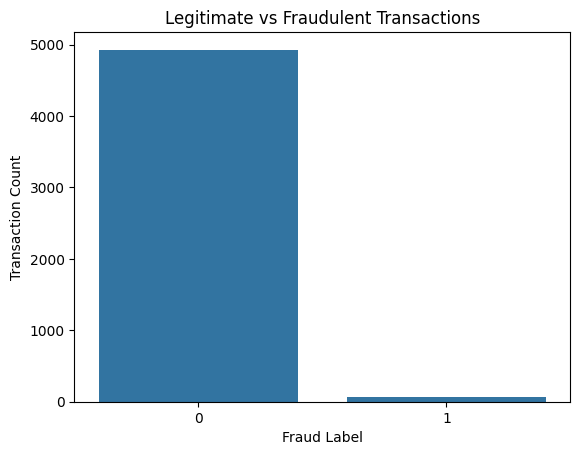

In [87]:
sns.countplot(
    data=df,
    x="fraud_label"
)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Count")
plt.show()

Notes : The target variable fraud_label represents the transaction class. A value of 0 represents a legitimate transaction and 1 represents a fraudulent transaction. The target distribution was analyzed to identify class imbalance before model training.

In [88]:
df.isnull().sum()

transaction_id             0
customer_id                0
customer_segment           0
account_type               0
transaction_timestamp      0
transaction_date           0
transaction_hour           0
transaction_dow            0
is_weekend                 0
is_holiday                 0
month                      0
quarter                    0
amount                     0
currency                   0
old_balance                0
new_balance                0
balance_delta_check        0
merchant_name              0
merchant_id                0
mcc_code                   0
mcc_category               0
merchant_sector            0
payment_rail               0
transaction_status         0
is_international           0
is_round_amount            0
device_id                  0
device_type                0
device_os                  0
trusted_device_count       0
new_device_flag            0
ip_address                 0
city                       0
country                    0
distance_from_

In [89]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [90]:
df = df.drop_duplicates().reset_index(drop=True)

print("New shape:", df.shape)

New shape: (5000, 43)


DATA LEAKAGE CHECK

Identify Leakage/Identifier Columns

In [91]:
drop_columns = [
    "transaction_id",
    "customer_id",
    "merchant_name",
    "merchant_id",
    "device_id",
    "ip_address",
    "fraud_type",
    "chargeback_flag"
]

print(drop_columns)

['transaction_id', 'customer_id', 'merchant_name', 'merchant_id', 'device_id', 'ip_address', 'fraud_type', 'chargeback_flag']


Transaction Amount Distribution

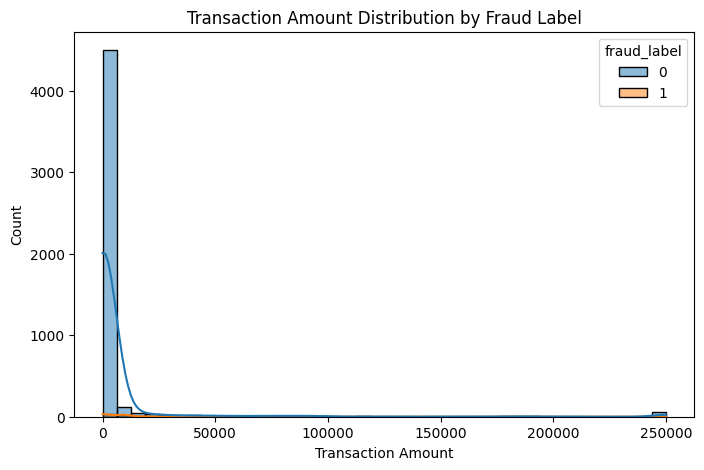

In [92]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="amount",
    hue="fraud_label",
    bins=40,
    kde=True
)

plt.title("Transaction Amount Distribution by Fraud Label")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")

plt.show()

Transaction amount distributions were compared between legitimate and fraudulent transactions to determine whether transaction size provides useful information for fraud classification.

Fraud Rate by International Transaction

In [93]:
international_fraud = (
    df.groupby("is_international")["fraud_label"]
    .mean()
    .mul(100)
)

print(international_fraud)

is_international
0    1.557038
1    1.295197
Name: fraud_label, dtype: float64


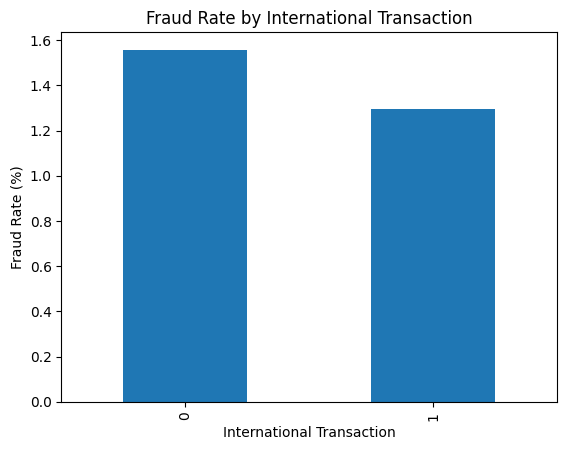

In [94]:
international_fraud.plot(
    kind="bar"
)

plt.title("Fraud Rate by International Transaction")
plt.xlabel("International Transaction")
plt.ylabel("Fraud Rate (%)")

plt.show()

Fraud Rate by New Device

Interpretation

This checks whether the fraud rate differs between known and newly observed devices.

new_device_flag
False     1.230087
True     29.268293
Name: fraud_label, dtype: float64


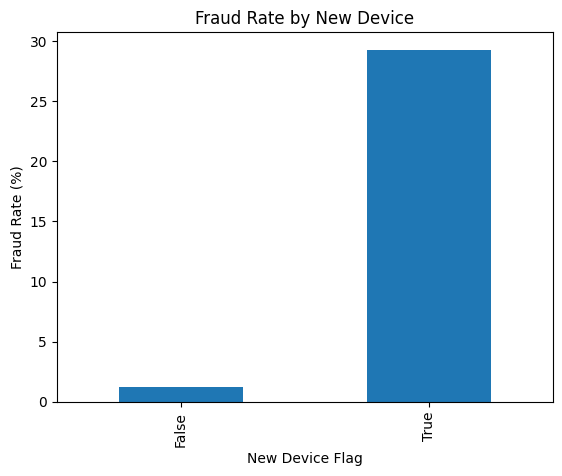

In [95]:
device_fraud = (
    df.groupby("new_device_flag")["fraud_label"]
    .mean()
    .mul(100)
)

print(device_fraud)

device_fraud.plot(kind="bar")

plt.title("Fraud Rate by New Device")
plt.xlabel("New Device Flag")
plt.ylabel("Fraud Rate (%)")

plt.show()

Fraud Rate by Transaction Hour

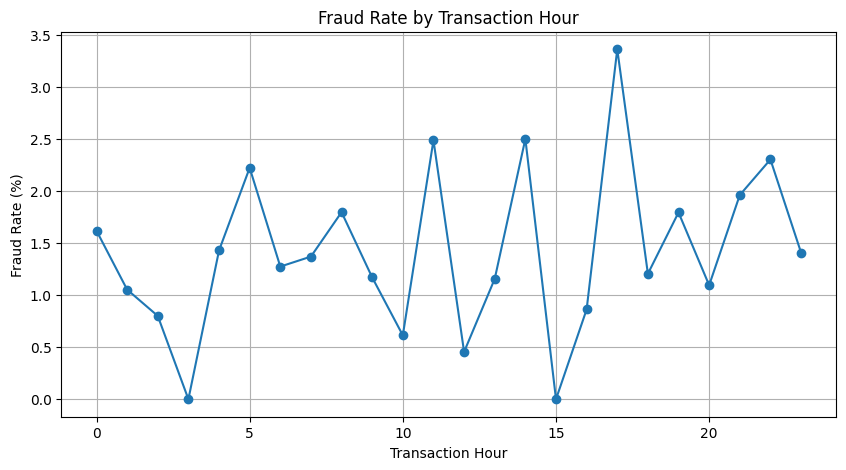

In [96]:
hour_fraud = (
    df.groupby("transaction_hour")["fraud_label"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10,5))

hour_fraud.plot(
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.grid(True)

plt.show()

Fraud Rate by Transaction Velocity

Interpretation

Transaction velocity represents the number of transactions associated with the customer within the previous hour.

A high velocity may be an important behavioral signal.

In [97]:
velocity_fraud = (
    df.groupby("transaction_velocity_1h")["fraud_label"]
    .mean()
    .mul(100)
)

print(
    velocity_fraud.head(20)
)

transaction_velocity_1h
1       0.680029
2       0.493421
3       0.807754
4       0.403226
5       1.449275
6       0.000000
7       0.000000
8     100.000000
9     100.000000
10    100.000000
11    100.000000
12    100.000000
13    100.000000
14    100.000000
16    100.000000
17    100.000000
18    100.000000
19    100.000000
20    100.000000
21    100.000000
Name: fraud_label, dtype: float64


Fraud Rate by Payment Rail

In [98]:
payment_fraud = (
    df.groupby("payment_rail")["fraud_label"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(payment_fraud)

payment_rail
SWIFT_WIRE        5.479452
ACH_TRANSFER      2.506964
CHECK             1.092896
P2P_TRANSFER      1.086957
CREDIT_CARD       0.855223
DEBIT_CARD        0.702371
CASH              0.000000
CRYPTO_GATEWAY    0.000000
Name: fraud_label, dtype: float64


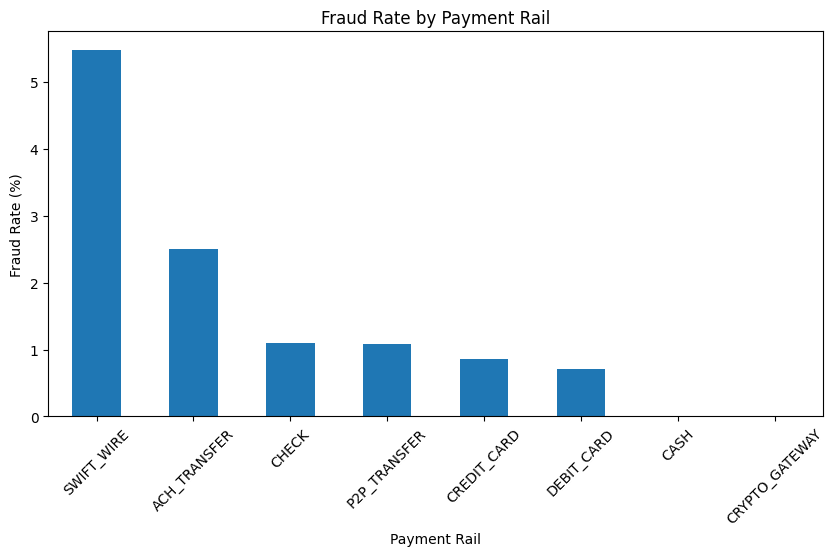

In [99]:
payment_fraud.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Fraud Rate by Payment Rail")
plt.xlabel("Payment Rail")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

Fraud Rate by Customer Segment

In [100]:
segment_fraud = (
    df.groupby("customer_segment")["fraud_label"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(segment_fraud)

customer_segment
FREQUENT_TRAVELER    1.690507
MASS_RETAIL          1.618123
HIGH_NET_WORTH       1.524390
STUDENT              1.517707
SMALL_BUSINESS       1.300881
Name: fraud_label, dtype: float64


Correlation Analysis

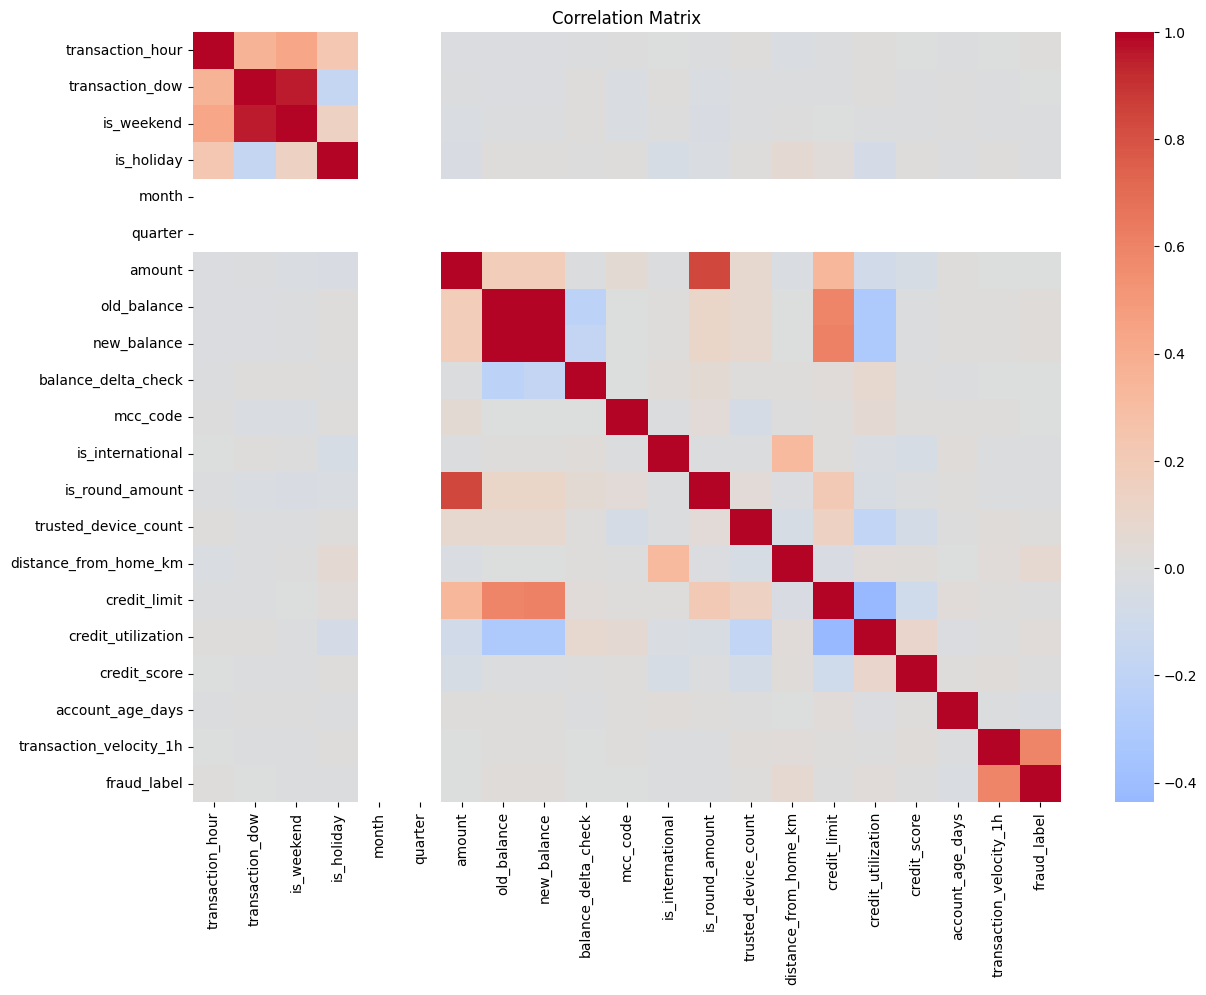

In [101]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

FEATURE ENGINEERING

Balance Change

In [102]:
df["balance_change"] = (
    df["new_balance"] -
    df["old_balance"]
)

print(df["balance_change"].head())

# This measures how much the balance changed during the transaction.

0     128.69
1    9300.80
2    -154.08
3    -127.43
4      15.00
Name: balance_change, dtype: float64


Amount-to-Balance Ratio

In [103]:
df["amount_balance_ratio"] = (
    df["amount"] /
    (df["old_balance"].abs() + 1)
)

print(df["amount_balance_ratio"].head())

#This tells us how large the transaction is relative to the previous account balance.

0    0.003033
1    0.132310
2    0.007609
3    0.051270
4    0.000601
Name: amount_balance_ratio, dtype: float64


High Value Transaction

In [104]:
amount_threshold = df["amount"].quantile(0.95)

df["high_value_transaction"] = (
    df["amount"] >= amount_threshold
).astype(int)

print(
    "High-value threshold:",
    amount_threshold
)

High-value threshold: 20991.236500000075


Combined Risk Indicator

In [105]:
df["risk_indicator"] = (
    df["is_international"].astype(int)
    + df["new_device_flag"].astype(int)
    + df["is_weekend"].astype(int)
    + df["is_holiday"].astype(int)
    + df["is_round_amount"].astype(int)
)

print(df["risk_indicator"].head())

0    2
1    2
2    3
3    3
4    2
Name: risk_indicator, dtype: int64


Check New Features

In [106]:
df[
    [
        "amount",
        "old_balance",
        "new_balance",
        "balance_change",
        "amount_balance_ratio",
        "high_value_transaction",
        "risk_indicator",
        "fraud_label"
    ]
].head(15)

,amount,old_balance,new_balance,balance_change,amount_balance_ratio,high_value_transaction,risk_indicator,fraud_label
0,128.69,42426.14,42554.83,128.69,0.003033,0,2,0
1,9300.80,70294.56,79595.36,9300.80,0.132310,0,2,0
2,154.08,20248.45,20094.37,-154.08,0.007609,0,3,0
3,127.43,2484.45,2357.02,-127.43,0.051270,0,3,0
4,15.00,24939.19,24954.19,15.00,0.000601,0,2,0
5,1433.85,117986.68,116552.83,-1433.85,0.012153,0,3,0
6,43.98,2973.48,2929.50,-43.98,0.014786,0,2,0
7,40.50,312990.90,312950.40,-40.50,0.000129,0,2,0
8,2751.68,326438.39,323686.71,-2751.68,0.008429,0,2,0
9,1.68,1264.83,1263.15,-1.68,0.001327,0,3,0


FEATURES SELECTION

In [107]:
#Numberical features to be used for modeling

numeric_features = [
    "transaction_hour",
    "transaction_dow",
    "is_weekend",
    "is_holiday",
    "month",
    "quarter",
    "amount",
    "old_balance",
    "new_balance",
    "balance_change",
    "amount_balance_ratio",
    "is_international",
    "is_round_amount",
    "trusted_device_count",
    "new_device_flag",
    "distance_from_home_km",
    "credit_limit",
    "credit_utilization",
    "credit_score",
    "account_age_days",
    "transaction_velocity_1h",
    "high_value_transaction",
    "risk_indicator"
]

In [108]:
#categorical features to be used for modeling

categorical_features = [
    "customer_segment",
    "account_type",
    "currency",
    "mcc_category",
    "merchant_sector",
    "payment_rail",
    "transaction_status",
    "device_type",
    "country"
]

In [109]:
features = (
    numeric_features +
    categorical_features
)

X = df[features].copy()

y = df["fraud_label"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 32)
y shape: (5000,)


TRAIN / VALIDATION / TEST SPLIT

70% Training

15% Validation

15% Testing

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (3500, 32)
Validation: (750, 32)
Testing: (750, 32)


PREPROCESSING

In [111]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [112]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)

X_test_processed = preprocessor.transform(
    X_test
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed validation shape:",
    X_val_processed.shape
)

print(
    "Processed test shape:",
    X_test_processed.shape
)

Processed training shape: (3500, 122)
Processed validation shape: (750, 122)
Processed test shape: (750, 122)


 Fit.transform() used for train a data.

 transform() used for validattion test. that prevent data leakage

In [113]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "Number of model features:",
    len(feature_names)
)

print(
    feature_names[:20]
)

# These names will later be used by SHAP.

Number of model features: 122
['num__transaction_hour' 'num__transaction_dow' 'num__is_weekend'
 'num__is_holiday' 'num__month' 'num__quarter' 'num__amount'
 'num__old_balance' 'num__new_balance' 'num__balance_change'
 'num__amount_balance_ratio' 'num__is_international'
 'num__is_round_amount' 'num__trusted_device_count' 'num__new_device_flag'
 'num__distance_from_home_km' 'num__credit_limit'
 'num__credit_utilization' 'num__credit_score' 'num__account_age_days']


CLASS IMBALANCE

In [114]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

#If fraud is the minority class, class weights give additional importance to fraud examples during training.

{np.int64(0): np.float64(0.5073934473760511), np.int64(1): np.float64(34.31372549019608)}


BASELINE MODEL

In [115]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

baseline_model.fit(
    X_train_processed,
    y_train
)

print("Baseline model trained successfully")

Baseline model trained successfully


Prediction & Evaluation

In [116]:
baseline_probability = (
    baseline_model
    .predict_proba(X_test_processed)[:, 1]
)

baseline_prediction = (
    baseline_probability >= 0.50
).astype(int)

In [117]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_prediction
)

baseline_precision = precision_score(
    y_test,
    baseline_prediction,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_prediction,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_prediction,
    zero_division=0
)

baseline_roc_auc = roc_auc_score(
    y_test,
    baseline_probability
)

baseline_pr_auc = average_precision_score(
    y_test,
    baseline_probability
)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1:", baseline_f1)
print("Baseline ROC-AUC:", baseline_roc_auc)
print("Baseline PR-AUC:", baseline_pr_auc)

Baseline Accuracy: 0.98
Baseline Precision: 0.4090909090909091
Baseline Recall: 0.8181818181818182
Baseline F1: 0.5454545454545454
Baseline ROC-AUC: 0.9880674129659245
Baseline PR-AUC: 0.8136986301369864


BUILD DEEP LEARNING MODEL

In [118]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Input
)

tf.random.set_seed(42)
np.random.seed(42)

input_dimension = X_train_processed.shape[1]

model = Sequential([
    
    Input(shape=(input_dimension,)),
    
    Dense(
        128,
        activation="relu"
    ),
    
    Dropout(0.30),
    
    Dense(
        64,
        activation="relu"
    ),
    
    Dropout(0.20),
    
    Dense(
        32,
        activation="relu"
    ),
    
    Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,113 (102.00 KB)

 Trainable params: 26,113 (102.00 KB)

 Non-trainable params: 0 (0.00 B)

Complie Model

In [119]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

EARLY STOPPING

In [120]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

The model can train for up to 50 epochs, but if validation loss doesn't improve for 5 consecutive epochs, training stops.

TRAIN DEEP LEARNING MODEL

In [121]:
history = model.fit(
    X_train_processed,
    y_train,
    
    validation_data=(
        X_val_processed,
        y_val
    ),
    
    epochs=50,
    batch_size=32,
    
    class_weight=class_weights,
    
    callbacks=[
        early_stopping
    ],
    
    verbose=1
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9451 - loss: 0.7381 - precision: 0.1061 - recall: 0.3725 - val_accuracy: 0.9760 - val_loss: 0.3400 - val_precision: 0.3478 - val_recall: 0.7273
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9489 - loss: 0.3660 - precision: 0.1768 - recall: 0.6863 - val_accuracy: 0.9493 - val_loss: 0.2270 - val_precision: 0.1860 - val_recall: 0.7273
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9423 - loss: 0.2808 - precision: 0.1814 - recall: 0.8431 - val_accuracy: 0.9400 - val_loss: 0.2006 - val_precision: 0.1600 - val_recall: 0.7273
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9557 - loss: 0.1968 - precision: 0.2374 - recall: 0.9216 - val_accuracy: 0.9653 - val_loss: 0.1110 - val_precision: 0.2581 - val_recall: 0.7273
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9657 - loss: 0.1448 - precision: 0.2883 - recall: 0.9216 - val_accuracy: 0.9613 - val_loss: 0.

TRAINING VS VALIDATION LOSS

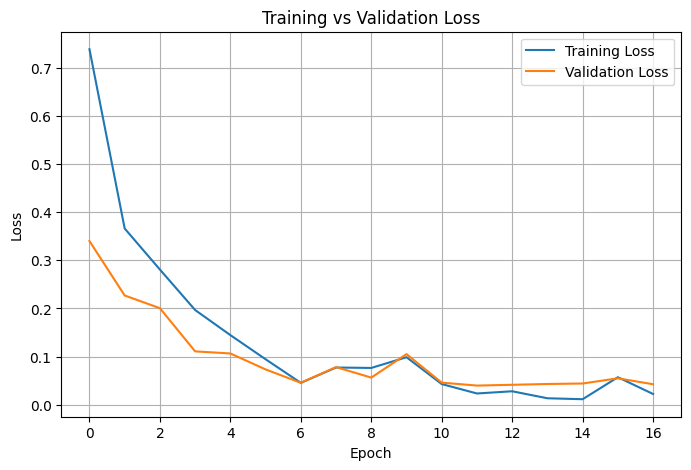

In [122]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

Obersvation

Training loss measures model error on training data, while validation loss measures performance on unseen validation data. A decreasing training loss indicates learning. A validation loss that remains reasonably stable without a sustained increase indicates that severe overfitting is not evident.

TRAINING VS VALIDATION ACCURACY

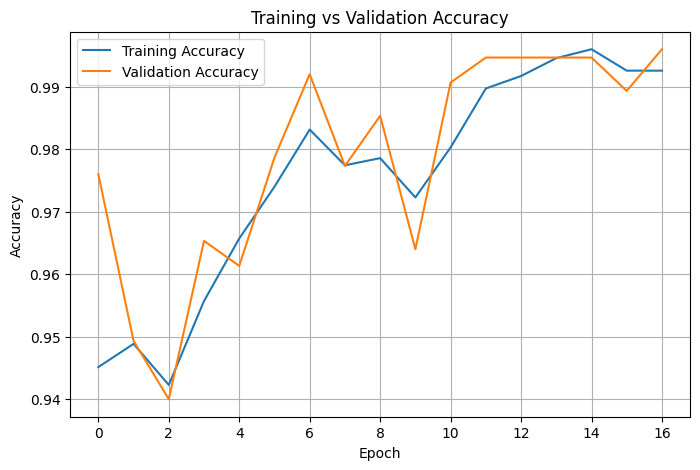

In [123]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

Oberservation

The Deep Neural Network achieved approximately 99%+ training and validation accuracy during training. The EarlyStopping mechanism stopped training at Epoch 17 because the validation loss stopped improving. This indicates that the model learned the patterns in the training data effectively.

DEEP LEARNING PREDICTIONS

In [124]:
y_probability = (
    model
    .predict(
        X_test_processed,
        verbose=0
    )
    .ravel()
)

print(y_probability[:10])

[9.0168659e-03 1.3313572e-04 9.3538974e-06 2.7695589e-03 3.2532294e-04
 5.8703794e-05 2.8032303e-01 6.3848705e-07 4.3865698e-03 8.5670385e-04]


In [125]:
y_pred_50 = (
    y_probability >= 0.50
).astype(int)

CONFUSION MATRIX

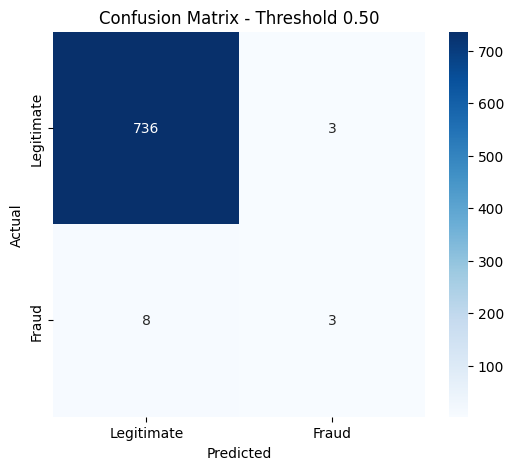

In [126]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_50
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Legitimate",
        "Fraud"
    ],
    yticklabels=[
        "Legitimate",
        "Fraud"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - Threshold 0.50"
)

plt.show()

A confusion matrix shows how well your fraud detection model classified legitimate transactions (0) and fraudulent transactions (1).

|                           | **Predicted 0 – Legitimate** | **Predicted 1 – Fraud** |
| ------------------------- | ---------------------------: | ----------------------: |
| **Actual 0 – Legitimate** |                       **TN** |                  **FP** |
| **Actual 1 – Fraud**      |                       **FN** |                  **TP** |


TN - Legitimate transaction → correctly predicted as legitimate.

FN - Fraudulent transaction → incorrectly predicted as legitimate.

FP - Legitimate transaction → incorrectly predicted as fraud.

TP - Fraudulent transaction → correctly predicted as fraud.


CLASSIFICATION REPORT

In [127]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_50,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99       739
       Fraud       0.50      0.27      0.35        11

    accuracy                           0.99       750
   macro avg       0.74      0.63      0.67       750
weighted avg       0.98      0.99      0.98       750



In [128]:
accuracy = accuracy_score(
    y_test,
    y_pred_50
)

precision = precision_score(
    y_test,
    y_pred_50,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_50,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_50,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

pr_auc = average_precision_score(
    y_test,
    y_probability
)

print("Deep Learning Model")
print("----------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))
print("PR-AUC   :", round(pr_auc, 4))

Deep Learning Model
----------------------------
Accuracy : 0.9853
Precision: 0.5
Recall   : 0.2727
F1 Score : 0.3529
ROC-AUC  : 0.9323
PR-AUC   : 0.407


THRESHOLD TUNING

In [129]:
thresholds = np.arange(
    0.20,
    0.81,
    0.05
)

threshold_results = []

for threshold in thresholds:
    
    predictions = (
        y_probability >= threshold
    ).astype(int)
    
    precision_value = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    recall_value = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    f1_value = f1_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    threshold_results.append([
        threshold,
        precision_value,
        recall_value,
        f1_value
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.20,0.333333,0.363636,0.347826
1,0.25,0.363636,0.363636,0.363636
2,0.30,0.400000,0.363636,0.380952
3,0.35,0.428571,0.272727,0.333333
4,0.40,0.428571,0.272727,0.333333
5,0.45,0.428571,0.272727,0.333333
6,0.50,0.500000,0.272727,0.352941
7,0.55,0.500000,0.272727,0.352941
8,0.60,0.500000,0.272727,0.352941
9,0.65,0.500000,0.272727,0.352941


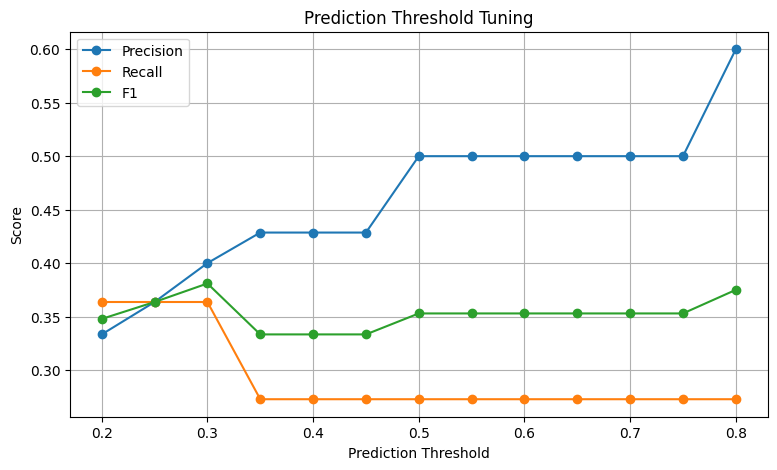

In [130]:
plt.figure(figsize=(9,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Prediction Threshold")
plt.ylabel("Score")

plt.title(
    "Prediction Threshold Tuning"
)

plt.legend()
plt.grid(True)

plt.show()

In [131]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = float(
    best_row["Threshold"]
)

print(
    "Selected Threshold:",
    best_threshold
)

print(
    "Precision:",
    best_row["Precision"]
)

print(
    "Recall:",
    best_row["Recall"]
)

print(
    "F1:",
    best_row["F1"]
)

Selected Threshold: 0.3
Precision: 0.4
Recall: 0.36363636363636365
F1: 0.38095238095238093


In [132]:
final_threshold = best_threshold

In [133]:
final_prediction = (
    y_probability >= final_threshold
).astype(int)

In [134]:
final_precision = precision_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_accuracy = accuracy_score(
    y_test,
    final_prediction
)

print("Final Tuned Model")
print("----------------------------")
print("Threshold:", final_threshold)
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1       :", round(final_f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))
print("PR-AUC   :", round(pr_auc, 4))

Final Tuned Model
----------------------------
Threshold: 0.3
Accuracy : 0.9827
Precision: 0.4
Recall   : 0.3636
F1       : 0.381
ROC-AUC  : 0.9323
PR-AUC   : 0.407


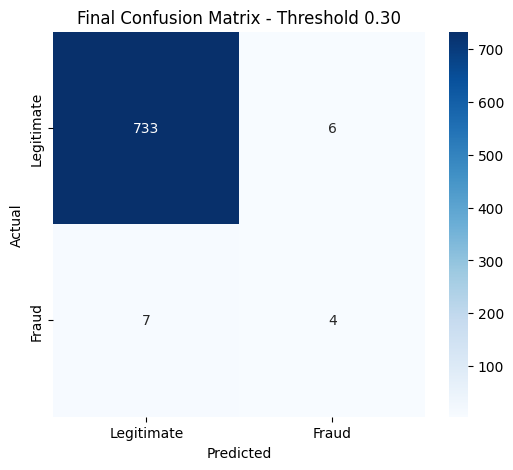

In [135]:
final_cm = confusion_matrix(
    y_test,
    final_prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Legitimate",
        "Fraud"
    ],
    yticklabels=[
        "Legitimate",
        "Fraud"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Final Confusion Matrix - Threshold {final_threshold:.2f}"
)

plt.show()

ROC CURVE

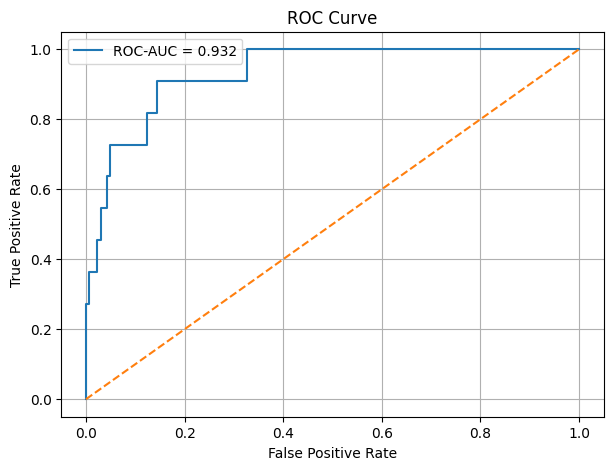

In [136]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

PRECISION-RECALL CURVE

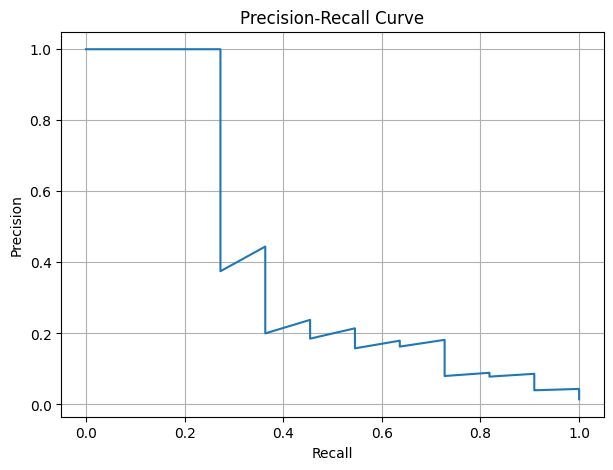

In [137]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_probability
    )
)

plt.figure(figsize=(7,5))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

COMPARE BASELINE VS DEEP LEARNING

In [138]:
comparison = pd.DataFrame({
    
    "Model": [
        "Logistic Regression",
        "Deep Learning"
    ],
    
    "Accuracy": [
        baseline_accuracy,
        final_accuracy
    ],
    
    "Precision": [
        baseline_precision,
        final_precision
    ],
    
    "Recall": [
        baseline_recall,
        final_recall
    ],
    
    "F1": [
        baseline_f1,
        final_f1
    ],
    
    "ROC-AUC": [
        baseline_roc_auc,
        roc_auc
    ],
    
    "PR-AUC": [
        baseline_pr_auc,
        pr_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.980000,0.409091,0.818182,0.545455,0.988067,0.813699
1,Deep Learning,0.982667,0.400000,0.363636,0.380952,0.932341,0.407009


In [139]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


Create SHAP Explainer

In [140]:
background_size = min(
    50,
    len(X_train_processed)
)

explanation_size = min(
    100,
    len(X_test_processed)
)

background_data = (
    X_train_processed[
        :background_size
    ]
)

explanation_data = (
    X_test_processed[
        :explanation_size
    ]
)

explainer = shap.Explainer(
    lambda x: model.predict(
        x,
        verbose=0
    ).ravel(),
    background_data
)

shap_values = explainer(
    explanation_data
)

print("SHAP analysis completed")

PermutationExplainer explainer: 101it [00:49,  1.91it/s]                         

SHAP analysis completed


SHAP GLOBAL IMPORTANCE

In [143]:
import numpy as np

shap_values.feature_names = feature_names

shap.plots.bar(
    shap_values,
    max_display=15
)

AttributeError: 'numpy.ndarray' object has no attribute 'items'

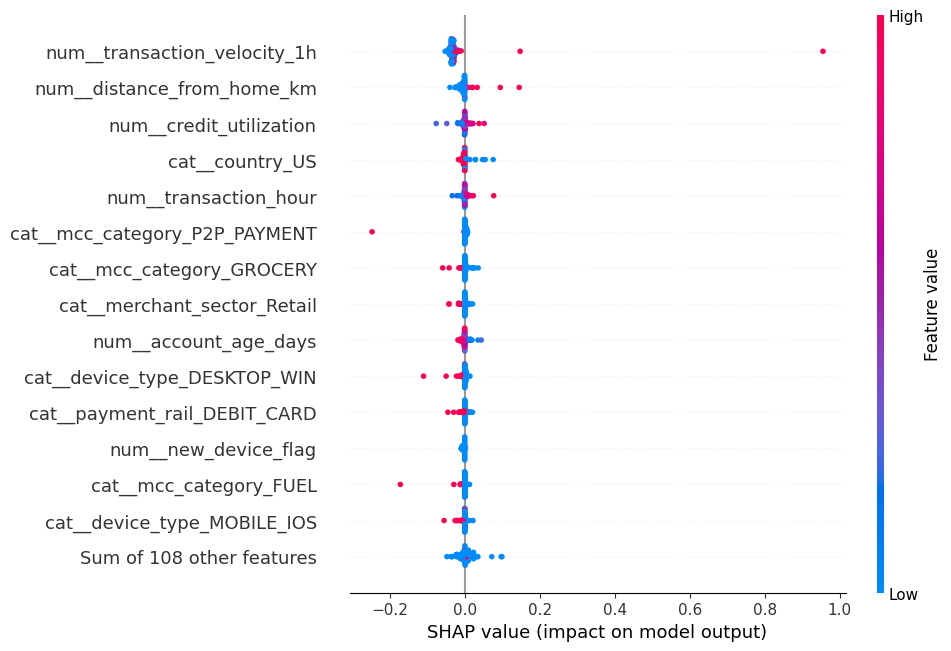

In [144]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

Note :

SHAP was used to improve model explainability. The global SHAP analysis identifies the features that contribute most strongly to model predictions. This provides greater transparency than simply presenting the final fraud classification

INDIVIDUAL TRANSACTION EXPLANATION

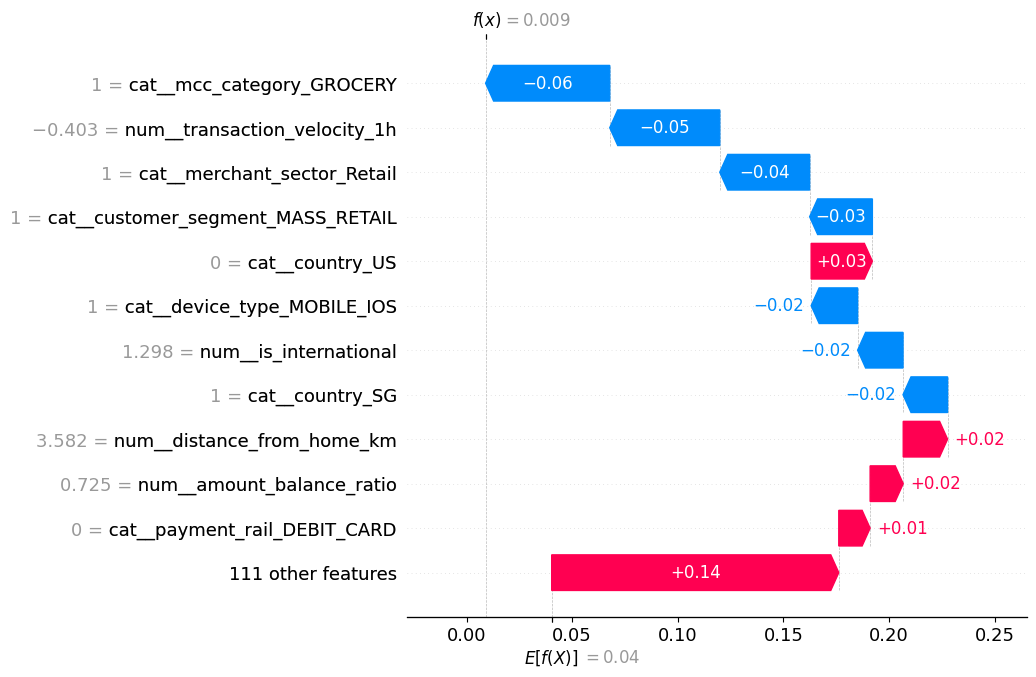

In [145]:
shap.plots.waterfall(
    shap_values[0],
    max_display=12
)

RISK SCORE

In [146]:
risk_scores = (
    y_probability * 100
)

In [147]:
def get_risk_level(score):
    
    if score < 30:
        return "Low"
    
    elif score < 60:
        return "Medium"
    
    elif score < 80:
        return "High"
    
    else:
        return "Critical"

In [148]:
example_probability = 0.87

example_score = (
    example_probability * 100
)

example_level = get_risk_level(
    example_score
)

print("Probability:", example_probability)
print("Risk Score:", example_score)
print("Risk Level:", example_level)

Probability: 0.87
Risk Score: 87.0
Risk Level: Critical


In [153]:
results_df = X_test.copy()

results_df["actual_fraud"] = (
    y_test.values
)

results_df["fraud_probability"] = (
    y_probability
)

results_df["risk_score"] = (
    risk_scores
)

results_df["predicted_fraud"] = (
    final_prediction
)

results_df["risk_level"] = (
    results_df["risk_score"]
    .apply(get_risk_level)
)

results_df.head(30)

,transaction_hour,transaction_dow,is_weekend,is_holiday,month,quarter,amount,old_balance,new_balance,balance_change,...,merchant_sector,payment_rail,transaction_status,device_type,country,actual_fraud,fraud_probability,risk_score,predicted_fraud,risk_level
4523,23,6,1,0,1,1,2338.03,1619.17,1524.76,-94.41,...,Retail,P2P_TRANSFER,APPROVED,MOBILE_IOS,SG,0,9.016866e-03,0.901687,0,Low
2827,12,6,1,0,1,1,294.57,96688.66,96983.23,294.57,...,Retail,CREDIT_CARD,APPROVED,MOBILE_IOS,US,0,1.331357e-04,0.013314,0,Low
3627,18,6,1,0,1,1,17.29,239119.49,239102.20,-17.29,...,Retail,DEBIT_CARD,APPROVED,DESKTOP_WIN,US,0,9.353897e-06,0.000935,0,Low
3146,15,6,1,0,1,1,368.55,113678.17,113309.62,-368.55,...,E-Commerce,SWIFT_WIRE,APPROVED,MOBILE_ANDROID,US,0,2.769559e-03,0.276956,0,Low
402,13,5,1,1,1,1,7.49,848.72,841.23,-7.49,...,Transport,DEBIT_CARD,APPROVED,MOBILE_ANDROID,US,0,3.253229e-04,0.032532,0,Low
1702,4,6,1,0,1,1,172.31,18534.25,18361.94,-172.31,...,Pets,DEBIT_CARD,APPROVED,MOBILE_ANDROID,US,0,5.870379e-05,0.005870,0,Low
3521,17,6,1,0,1,1,3194.27,27353.82,30548.09,3194.27,...,Travel,CREDIT_CARD,APPROVED,DESKTOP_WIN,AU,0,2.803230e-01,28.032303,0,Low
2423,9,6,1,0,1,1,11.93,19565.97,19577.90,11.93,...,Automotive,CREDIT_CARD,APPROVED,DESKTOP_WIN,US,0,6.384871e-07,0.000064,0,Low
4635,23,6,1,0,1,1,177.23,156003.88,155826.65,-177.23,...,Retail,ACH_TRANSFER,APPROVED,MOBILE_IOS,US,0,4.386570e-03,0.438657,0,Low
4529,23,6,1,0,1,1,37.86,910.20,872.34,-37.86,...,Leisure,CASH,APPROVED,MOBILE_IOS,CA,0,8.567038e-04,0.085670,0,Low


In [154]:
model.save(
    "fraud_detection_model.keras"
)

print(
    "Deep Learning model saved."
)

Deep Learning model saved.


In [155]:
joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)

print(
    "Preprocessor saved."
)

Preprocessor saved.


In [156]:
with open(
    "threshold.json",
    "w"
) as file:
    
    json.dump(
        {
            "threshold": final_threshold
        },
        file
    )

print(
    "Threshold saved:",
    final_threshold
)

Threshold saved: 0.3


In [158]:

# SAVE FEATURE INFORMATION
metadata = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": "fraud_label",
    "threshold": final_threshold,
    "risk_bands": {
        "Low": "0-30",
        "Medium": "30-60",
        "High": "60-80",
        "Critical": "80-100"
    }
}

with open(
    "metadata.json",
    "w"
) as file:
    
    json.dump(
        metadata,
        file,
        indent=4
    )

print("Metadata saved.")

Metadata saved.
